In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
import pickle
import matplotlib.pyplot as plt


## Data & preprocessing

In [14]:
freq      = "seasonal"
df        = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
block_cov = block_cov.set_index(['country', 'time_block'])

countries = df['country'].unique()
cont_map  = df.drop_duplicates('country').set_index('country')['continent'].to_dict()
cont_list = sorted(set(cont_map.values()))
cont_idx  = {c: i for i, c in enumerate(cont_list)}
n_cont    = len(cont_list)

all_blocks = sorted(df['time_block'].unique())
n_blocks   = len(all_blocks)
block_idx  = {b: i for i, b in enumerate(all_blocks)}

sigma2 = 0.03

print(df.columns.tolist())
print(block_cov.columns.tolist())


['country', 'date', 'log_cases', 'continent', 'pc1', 'pc2', 'time_block']
['stringency_lag', 'vac_lag', 'log_vac_lag']


## Model formulation

$$S_{t,c} = S_{t-1,c} + \mu_{t,c} + \epsilon, \quad \epsilon \sim N(0,\sigma^2)$$
$$Y_{t,c} = S_{t,c} + \alpha_c + \eta, \quad \eta \sim N(0,\tau^2)$$

**M0:** $\mu_{t,c} = \beta_0 + \beta_1 U_{c1} + \beta_2 U_{c2} + \beta_3 V_{\text{str}} + \beta_4 V_{\text{vac}} + \theta_c$

**M1:** $\mu_{t,c} = X_{t,c}^\top(\beta + \delta_{s(t)}) + \theta_c$ — adds season-specific deviation $\delta_s$ with strong ridge penalty shrinking toward 0.

**M2:** AR(1) augmented state $X_t=(S_t, S_{t-1})^\top$, transition $A(\rho)=\begin{pmatrix}1+\rho&-\rho\\1&0\end{pmatrix}$.


## Helper functions

In [ ]:
def get_block_covariates(country, time_block):
    key = (country, time_block)
    if key in block_cov.index:
        return (float(block_cov.loc[key, 'stringency_lag']),
                float(block_cov.loc[key, 'log_vac_lag']))
    return 0.0, 0.0


def compute_mu_t_c(df_c, beta, theta_c, delta=None):

    U_c1 = float(df_c['pc1'].iloc[0])
    U_c2 = float(df_c['pc2'].iloc[0])
    mu   = np.zeros(len(df_c))
    for i, (_, row) in enumerate(df_c.iterrows()):
        V_str, V_vac = get_block_covariates(df_c['country'].iloc[0], row['time_block'])
        X_t = np.array([1., U_c1, U_c2, V_str, V_vac])
        d_s = (delta.get(row['time_block'], np.zeros(5))
               if delta is not None else np.zeros(5))
        mu[i] = X_t @ (beta + d_s) + theta_c
    return mu


## Kalman filter & RTS smoother


In [16]:
# ── Scalar Kalman filter: M0 / M1 (identical to model.py) ────────────────────
def kalman_filter_scalar(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2=0.03):
    T       = len(Y)
    mu_f    = np.zeros(T);  Sigma_f = np.zeros(T)
    mu_p    = np.zeros(T);  Sigma_p = np.zeros(T)
    log_ml  = 0.0
    for t in range(T):
        if t == 0:
            mu_p[t]    = mu_s_1
            Sigma_p[t] = Sigma_s_1
        else:
            mu_p[t]    = mu_f[t-1] + mu_seq[t]
            Sigma_p[t] = Sigma_f[t-1] + sigma2
        innov      = Y[t] - log_pc - mu_p[t]
        H_t        = Sigma_p[t] + tau2
        K_t        = Sigma_p[t] / H_t
        mu_f[t]    = mu_p[t]    + K_t * innov
        Sigma_f[t] = (1 - K_t) * Sigma_p[t]
        log_ml    += -0.5 * (np.log(2 * np.pi * H_t) + innov**2 / H_t)
    return mu_f, Sigma_f, mu_p, Sigma_p, log_ml


# ── Scalar RTS smoother: M0 / M1 (identical to model.py) ─────────────────────
def rts_smoother_scalar(mu_f, Sigma_f, mu_p, Sigma_p):
    T             = len(mu_f)
    mu_s          = mu_f.copy();  Sigma_s = Sigma_f.copy()
    Sigma_s_cross = np.zeros(T - 1)
    for t in range(T - 2, -1, -1):
        G_t              = Sigma_f[t] / Sigma_p[t + 1]
        mu_s[t]          = mu_f[t]    + G_t * (mu_s[t+1]    - mu_p[t+1])
        Sigma_s[t]       = Sigma_f[t] + G_t**2 * (Sigma_s[t+1] - Sigma_p[t+1])
        Sigma_s_cross[t] = G_t * Sigma_s[t+1]
    return mu_s, Sigma_s, Sigma_s_cross


# ── 2-D Kalman filter: M2 ─────────────────────────────────────────────────────
def kalman_filter_2d(Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, rho, sigma2=0.03):
    T   = len(Y)
    C   = np.array([1., 0.])
    Q2  = sigma2 * np.array([[1., 0.], [0., 0.]])
    A   = np.array([[1 + rho, -rho], [1., 0.]])

    mu_f_2  = np.zeros((T, 2));  Sig_f_2 = np.zeros((T, 2, 2))
    mu_p_2  = np.zeros((T, 2));  Sig_p_2 = np.zeros((T, 2, 2))
    log_ml  = 0.0
    for t in range(T):
        if t == 0:
            mu_p_2[t]  = np.array([mu_s_1, mu_s_1])
            Sig_p_2[t] = np.diag([Sigma_s_1, Sigma_s_1])
        else:
            mu_p_2[t]  = A @ mu_f_2[t-1] + np.array([mu_seq[t], 0.])
            Sig_p_2[t] = A @ Sig_f_2[t-1] @ A.T + Q2
        innov      = Y[t] - log_pc - C @ mu_p_2[t]
        H_t        = float(C @ Sig_p_2[t] @ C) + tau2
        H_t        = max(H_t, 1e-8)
        K_t        = (Sig_p_2[t] @ C) / H_t
        mu_f_2[t]  = mu_p_2[t] + K_t * innov
        Sig_f_2[t] = (np.eye(2) - np.outer(K_t, C)) @ Sig_p_2[t]
        log_ml    += -0.5 * (np.log(2 * np.pi * H_t) + innov**2 / H_t)
    return mu_f_2, Sig_f_2, mu_p_2, Sig_p_2, log_ml


# ── 2-D RTS smoother: M2 ─────────────────────────────────────────────────────
def rts_smoother_2d(mu_f_2, Sig_f_2, mu_p_2, Sig_p_2, rho):
    T   = mu_f_2.shape[0]
    A   = np.array([[1 + rho, -rho], [1., 0.]])
    mu_s_2        = mu_f_2.copy();  Sig_s_2       = Sig_f_2.copy()
    Sig_s_cross_2 = np.zeros((T - 1, 2, 2))
    for t in range(T - 2, -1, -1):
        Sig_p_inv        = np.linalg.pinv(Sig_p_2[t+1] + 1e-10 * np.eye(2))
        G_t              = Sig_f_2[t] @ A.T @ Sig_p_inv
        mu_s_2[t]        = mu_f_2[t]  + G_t @ (mu_s_2[t+1]  - mu_p_2[t+1])
        Sig_s_2[t]       = Sig_f_2[t] + G_t @ (Sig_s_2[t+1] - Sig_p_2[t+1]) @ G_t.T
        Sig_s_cross_2[t] = G_t @ Sig_s_2[t+1]
    return mu_s_2, Sig_s_2, Sig_s_cross_2


## E-step

In [ ]:
def e_step(df, alpha, beta, theta, tau2, sigma2=0.03,
           delta=None, ar1=False, rho=0.0):

    results = {}
    log_ml  = 0.0

    for country in countries:
        df_c = (df[df['country'] == country]
                .sort_values('date')
                .reset_index(drop=True))
        Y      = df_c['log_cases'].values.astype(float)
        log_pc = alpha[country]
        mu_seq = compute_mu_t_c(df_c, beta, theta[country], delta=delta)

        mu_s_1    = float(Y[0] - log_pc)
        Sigma_s_1 = sigma2

        if ar1:
            mu_f_2, Sig_f_2, mu_p_2, Sig_p_2, lml = kalman_filter_2d(
                Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, rho, sigma2)
            mu_s_2, Sig_s_2, Sig_s_cross_2 = rts_smoother_2d(
                mu_f_2, Sig_f_2, mu_p_2, Sig_p_2, rho)

            # Sufficient stats from first component of augmented state
            ES  = mu_s_2[:, 0]
            ES2 = Sig_s_2[:, 0, 0] + mu_s_2[:, 0]**2
            # E[S_t * S_{t-1}] = Sig_s_cross_2[t][0,0] + mu_s_2[t,0]*mu_s_2[t-1,0]
            ESS = Sig_s_cross_2[:, 0, 0] + mu_s_2[1:, 0] * mu_s_2[:-1, 0]

            mu_f    = mu_f_2[:, 0];  Sigma_f = Sig_f_2[:, 0, 0]
            mu_p    = mu_p_2[:, 0];  Sigma_p = Sig_p_2[:, 0, 0]
        else:
            mu_f, Sigma_f, mu_p, Sigma_p, lml = kalman_filter_scalar(
                Y, log_pc, mu_seq, tau2, mu_s_1, Sigma_s_1, sigma2)
            mu_s, Sigma_s, Sigma_s_cross = rts_smoother_scalar(
                mu_f, Sigma_f, mu_p, Sigma_p)

            ES  = mu_s
            ES2 = Sigma_s + mu_s**2
            ESS = Sigma_s_cross + mu_s[1:] * mu_s[:-1]

            mu_s_2 = Sig_s_2 = mu_p_2 = Sig_p_2 = Sig_s_cross_2 = None

        log_ml += lml

        results[country] = {
            'ES'            : ES,
            'ES2'           : ES2,
            'ESS'           : ESS,
            'Y'             : Y,
            'mu_seq'        : mu_seq,
            'PC_c1'         : float(df_c['pc1'].iloc[0]),
            'PC_c2'         : float(df_c['pc2'].iloc[0]),
            'blocks'        : df_c['time_block'].tolist(),
            'dates'         : df_c['date'].tolist(),
            # M2-only (None for M0/M1)
            'mu_s_2'        : mu_s_2,
            'Sig_s_2'       : Sig_s_2,
            'mu_p_2'        : mu_p_2,
            'Sig_p_2'       : Sig_p_2,
            'Sig_s_cross_2' : Sig_s_cross_2,
        }

    return results, log_ml


## M-step

**tau2** — exact smoothed-state EM formula (identical to `model.py`):
$$\hat\tau^2 = \frac{1}{N}\sum_{t,c} E[(Y_{t,c}-\alpha_c-S_{t,c})^2 \mid Y]
= \frac{1}{N}\sum_{t,c}\bigl[(Y_{t,c}-\alpha_c)^2 - 2(Y_{t,c}-\alpha_c)E[S_{t,c}] + E[S_{t,c}^2]\bigr]$$

**alpha** — MAP with $\alpha_c\sim N(-1,1)$ prior (identical to `model.py`).

**beta / theta** (M0) — `Ridge(alpha=lam)` on raw design $[X_{t,c},\ e_{\text{cont}(c)}]$ (identical to `model.py`).

**beta / theta / delta** (M1/M2) — same ridge strength `lam` on beta+theta; separate `lam_delta` on $\delta_s$ block. Design scaled so Ridge(alpha=1) is equivalent.

**rho** (M2) — exact EM via 2×2 RTS cross-covariances.


In [ ]:
def m_step(df, results, alpha, tau2, lam=1.0,
           delta=None, lam_delta=5.0, ar1=False, rho=0.0):

    # ── Step 1: ridge regression for beta (+delta) + theta ────────────────────
    rows_y, rows_x = [], []

    for country in countries:
        res   = results[country]
        df_c  = df[df['country'] == country].sort_values('date').reset_index(drop=True)
        T     = len(df_c)
        PC_c1 = res['PC_c1'];  PC_c2 = res['PC_c2']
        cont  = cont_map[country]

        if ar1 and res['mu_s_2'] is not None:
            # D_t = S_t - S_{t-1} read directly from augmented state (exact)
            delta_S = res['mu_s_2'][1:, 0] - res['mu_s_2'][1:, 1]
        else:
            delta_S = res['ES'][1:] - res['ES'][:-1]

        for t in range(T - 1):
            V_str, V_vac = get_block_covariates(country, df_c['time_block'].iloc[t+1])
            X_t  = np.array([1., PC_c1, PC_c2, V_str, V_vac])
            cont_dummy = np.zeros(n_cont)
            cont_dummy[cont_idx[cont]] = 1.0

            if delta is None:
                # M0: exact same design as model.py
                rows_x.append(np.concatenate([X_t, cont_dummy]))
            else:
                # M1/M2: add delta_s block
                b  = df_c['time_block'].iloc[t+1]
                bi = block_idx[b]
                delta_block = np.zeros(n_blocks * 5)
                delta_block[bi*5: bi*5+5] = X_t
                rows_x.append(np.concatenate([X_t, delta_block, cont_dummy]))

            rows_y.append(delta_S[t])

    y_reg = np.array(rows_y)
    X_reg = np.array(rows_x)

    if delta is None:
        # M0: identical to model.py — Ridge(alpha=lam) on raw X
        ridge    = Ridge(alpha=lam, fit_intercept=False)
        ridge.fit(X_reg, y_reg)
        coefs    = ridge.coef_
        beta_new = coefs[:5]
        theta_raw = coefs[5:].copy()
        delta_new = None
    else:
        # M1/M2: separate penalties via sqrt-scaling trick
        # beta block: lam, delta block: lam_delta, theta block: lam
        n_beta_cols  = 5
        n_delta_cols = n_blocks * 5
        n_theta_cols = n_cont
        penalty = np.concatenate([
            np.full(n_beta_cols,  lam),
            np.full(n_delta_cols, lam_delta),
            np.full(n_theta_cols, lam),
        ])
        scale    = np.sqrt(penalty)
        X_scaled = X_reg / scale[np.newaxis, :]
        ridge    = Ridge(alpha=1.0, fit_intercept=False)
        ridge.fit(X_scaled, y_reg)
        coefs    = ridge.coef_ / scale

        beta_new  = coefs[:n_beta_cols]
        delta_raw = coefs[n_beta_cols: n_beta_cols + n_delta_cols]
        delta_new = {b: delta_raw[block_idx[b]*5: block_idx[b]*5+5].copy()
                     for b in all_blocks}
        theta_raw = coefs[n_beta_cols + n_delta_cols:].copy()

    # sum-to-zero identifiability on theta (identical to model.py)
    theta_raw -= theta_raw.mean()
    theta_new  = {c: float(theta_raw[cont_idx[cont_map[c]]]) for c in countries}

    # ── Step 2: tau2 — exact smoothed-state formula (identical to model.py) ───
    tau2_num, N_tau = 0.0, 0
    for country in countries:
        res    = results[country]
        Y      = res['Y'];  ES = res['ES'];  ES2 = res['ES2']
        log_pc = alpha[country]
        Y_tilde   = Y - log_pc
        tau2_num += float(np.sum(Y_tilde**2 - 2*Y_tilde*ES + ES2))
        N_tau    += len(Y)
    tau2_new = max(tau2_num / N_tau, 1e-6)

    # ── Step 3: alpha MAP — N(-1,1) prior (identical to model.py) ────────────
    alpha_new = {}
    for country in countries:
        Y   = results[country]['Y'];  ES = results[country]['ES']
        T_c = len(Y)
        alpha_new[country] = float(
            (np.sum(Y - ES) / tau2_new - 1.0) / (T_c / tau2_new + 1.0))

    # ── Step 4: rho — exact EM via 2x2 smoother cross-covariances (M2) ───────
    rho_new = rho
    if ar1:
        c_vec = np.array([1., -1.])   # D_t = c^T X_t
        num_rho = 0.0;  den_rho = 0.0
        for country in countries:
            res           = results[country]
            mu_s_2        = res['mu_s_2']
            Sig_s_2       = res['Sig_s_2']
            Sig_s_cross_2 = res['Sig_s_cross_2']
            mu_seq        = res['mu_seq']
            if mu_s_2 is None: continue
            T = mu_s_2.shape[0]
            for t in range(1, T):
                ED_lag_sq = c_vec @ Sig_s_2[t-1] @ c_vec + (c_vec @ mu_s_2[t-1])**2
                ED_cross  = c_vec @ Sig_s_cross_2[t-1] @ c_vec + (c_vec @ mu_s_2[t]) * (c_vec @ mu_s_2[t-1])
                num_rho  += ED_cross - mu_seq[t] * (c_vec @ mu_s_2[t-1])
                den_rho  += ED_lag_sq
        rho_new = float(np.clip(num_rho / (den_rho + 1e-8), -0.95, 0.95))

    return beta_new, delta_new, theta_new, tau2_new, alpha_new, rho_new


## EM runner

In [ ]:
def run_EM(df, label, n_iter=1000, lam=1.0, lam_delta=5.0,
           tol=1e-4, ar1=False, rho_init=0.0, use_delta=False):
    print(f"\n{'='*55}\n  {label}")
    print(f"  lam={lam}  lam_delta={lam_delta if use_delta else 'N/A'}  ar1={ar1}")
    print(f"{'='*55}")

    beta  = np.zeros(5)
    delta = ({b: np.zeros(5) for b in all_blocks} if use_delta else None)
    theta = {c: 0.0 for c in countries}
    tau2  = 0.01
    alpha = {c: 0.0 for c in countries}
    rho   = rho_init
    log_mls = []

    for it in range(n_iter):
        results, log_ml = e_step(df, alpha, beta, theta, tau2,
                                  sigma2=sigma2, delta=delta, ar1=ar1, rho=rho)
        log_mls.append(log_ml)

        beta, delta, theta, tau2, alpha, rho = m_step(
            df, results, alpha, tau2,
            lam=lam, delta=delta, lam_delta=lam_delta, ar1=ar1, rho=rho)

        if it % 50 == 0 or it == n_iter - 1:
            print(f"  iter {it+1:3d}  log_ml={log_ml:10.2f}  tau2={tau2:.5f}"
                  + (f"  rho={rho:.4f}" if ar1 else ""))

        if it > 0 and abs(log_mls[-1] - log_mls[-2]) < tol:
            print(f"  Converged at iteration {it+1}");  break

    return {'label': label, 'results': results,
            'beta': beta, 'delta': delta, 'theta': theta,
            'tau2': tau2, 'alpha': alpha, 'rho': rho,
            'log_mls': log_mls, 'final_log_ml': log_mls[-1]}


## Fit models

| Model | `use_delta` | `ar1` | `lam` | Notes |
|---|---|---|---|---|
| **M0** | `False` | `False` | `1.0` | Identical to `model.py` |
| **M1** | `True` | `False` | `1.0` | + regularised $\delta_s$ |
| **M2** | `True` | `True` | `1.0` | + AR(1) increment |


In [20]:
# M0 — identical to model.py
m0 = run_EM(df, label="M0 — baseline",
            lam=1.0, use_delta=False, ar1=False)

# M1 — +seasonal drift delta_s
m1 = run_EM(df, label="M1 — +seasonal drift delta_s",
            lam=1.0, lam_delta=5.0, use_delta=True, ar1=False)

# M2 — +AR(1) increment
m2 = run_EM(df, label="M2 — +AR(1) increment",
            lam=1.0, lam_delta=5.0, use_delta=True, ar1=True, rho_init=0.0)

all_models = [m0, m1, m2]



  M0 — baseline
  lam=1.0  lam_delta=N/A  ar1=False
  iter   1  log_ml= -30587.26  tau2=0.01602


KeyboardInterrupt: 

## Performance table & convergence

                       Model  Final log-ML Δ log-ML    tau2    rho
               M0 — baseline     -20538.27        — 0.27789 0.0000
M1 — +seasonal drift delta_s     -18057.90  2480.37 0.21648 0.0000
       M2 — +AR(1) increment     -10998.81  7059.09 0.04961 0.6636


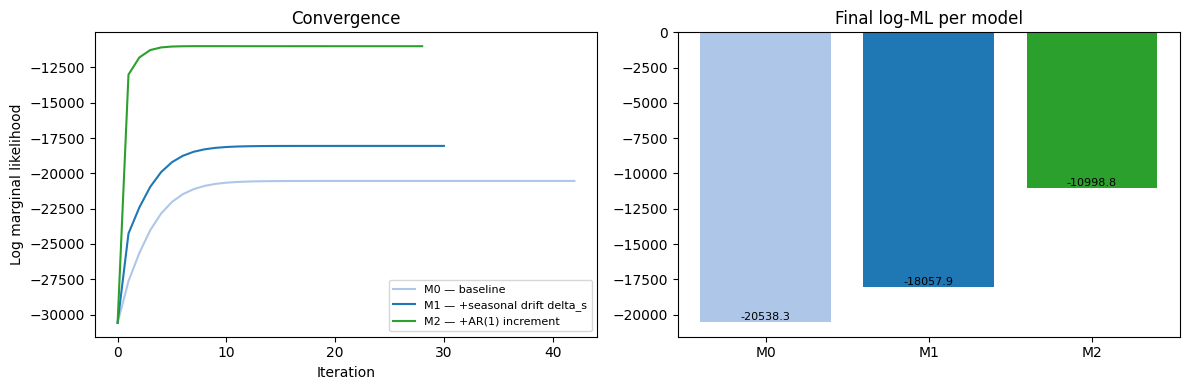

In [ ]:
rows = []
for i, m in enumerate(all_models):
    delta_lml = ('—' if i == 0
                 else round(m['final_log_ml'] - all_models[i-1]['final_log_ml'], 2))
    rows.append({
        'Model'        : m['label'],
        'Final log-ML' : round(m['final_log_ml'], 2),
        'Δ log-ML'     : delta_lml,
        'tau2'         : round(m['tau2'], 5),
        'rho'          : round(m['rho'], 4),
    })
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#aec7e8', '#1f77b4', '#2ca02c']
for m, col in zip(all_models, colors):
    axes[0].plot(m['log_mls'], label=m['label'], color=col)
axes[0].set_xlabel('Iteration');  axes[0].set_ylabel('Log marginal likelihood')
axes[0].set_title('Convergence');  axes[0].legend(fontsize=8)
labels = [m['label'].split('—')[0].strip() for m in all_models]
vals   = [m['final_log_ml'] for m in all_models]
bars   = axes[1].bar(labels, vals, color=colors)
axes[1].set_title('Final log-ML per model')
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'../data/model_convergence_{freq}.png', dpi=150, bbox_inches='tight')
plt.show()


## Save

In [ ]:
with open(f'../data/all_models_{freq}.pkl', 'wb') as f:
    pickle.dump(all_models, f)
print(f"Saved all_models_{freq}.pkl")

for m in all_models:
    tag     = m['label'].split('—')[0].strip().lower().replace(' ', '_')
    records = []
    for country in countries:
        ES    = m['results'][country]['ES']
        dates = m['results'][country]['dates']
        for t in range(1, len(ES)):
            records.append({'country': country, 'date': dates[t],
                            'R_plug_in': np.exp(ES[t] - ES[t-1]), 'model': m['label']})
    pd.DataFrame(records).to_csv(f'../data/R_plugin_{freq}_{tag}.csv', index=False)
print("Saved R plug-in CSVs")


Saved all_models_seasonal.pkl
Saved R plug-in CSVs
